# Cross-Product Correlation — Round 3

All 12 products: 2 base commodities + 10 VEV option strikes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

DATA_DIR = Path("../historical_data/round_3")
ALL_PRODUCTS = [
    "VELVETFRUIT_EXTRACT", "HYDROGEL_PACK",
    "VEV_4000","VEV_4500","VEV_5000","VEV_5100","VEV_5200",
    "VEV_5300","VEV_5400","VEV_5500","VEV_6000","VEV_6500",
]
STRIKES = [4000,4500,5000,5100,5200,5300,5400,5500,6000,6500]
days = [0, 1, 2]
day_colors = {0:"#4C72B0", 1:"#DD8452", 2:"#55A868"}

frames = []
for d in days:
    tmp = pd.read_csv(DATA_DIR / f"prices_round_3_day_{d}.csv", sep=";")
    frames.append(tmp)
raw = pd.concat(frames, ignore_index=True)

ticks_per_day = int(raw[raw["day"] == 0]["timestamp"].max() + 100)
raw["global_ts"] = (raw["day"] - days[0]) * ticks_per_day + raw["timestamp"]

wide = raw.pivot_table(index="global_ts", columns="product",
                       values="mid_price", aggfunc="first").sort_index().reset_index()
ts_map = raw.drop_duplicates("global_ts").set_index("global_ts")[["day","timestamp"]]
wide   = wide.join(ts_map, on="global_ts")

print(f"Wide shape: {wide.shape}")
print("Products present:", [c for c in ALL_PRODUCTS if c in wide.columns])
wide[ALL_PRODUCTS].describe().round(2)


Wide shape: (30000, 15)
Products present: ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


,VELVETFRUIT_EXTRACT,HYDROGEL_PACK,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.0,30000.0
mean,5250.10,9990.81,1250.11,750.11,255.02,166.81,95.55,46.76,15.95,6.64,0.5,0.5
std,15.63,31.94,15.65,15.64,14.38,12.74,9.66,6.23,3.43,1.74,0.0,0.0
min,5198.00,9891.00,1198.00,698.50,206.50,125.00,64.00,26.50,6.50,2.50,0.5,0.5
25%,5238.50,9967.50,1238.50,739.00,245.00,158.00,89.00,43.00,13.50,5.50,0.5,0.5
50%,5249.50,9994.00,1249.50,749.00,254.00,166.50,96.00,47.00,16.50,6.50,0.5,0.5
75%,5262.50,10013.00,1262.50,762.00,266.00,176.00,102.50,51.00,18.00,7.50,0.5,0.5
max,5300.00,10079.00,1300.00,799.50,300.50,205.50,122.50,65.50,27.00,12.50,0.5,0.5


## 1 — Full Correlation Matrix

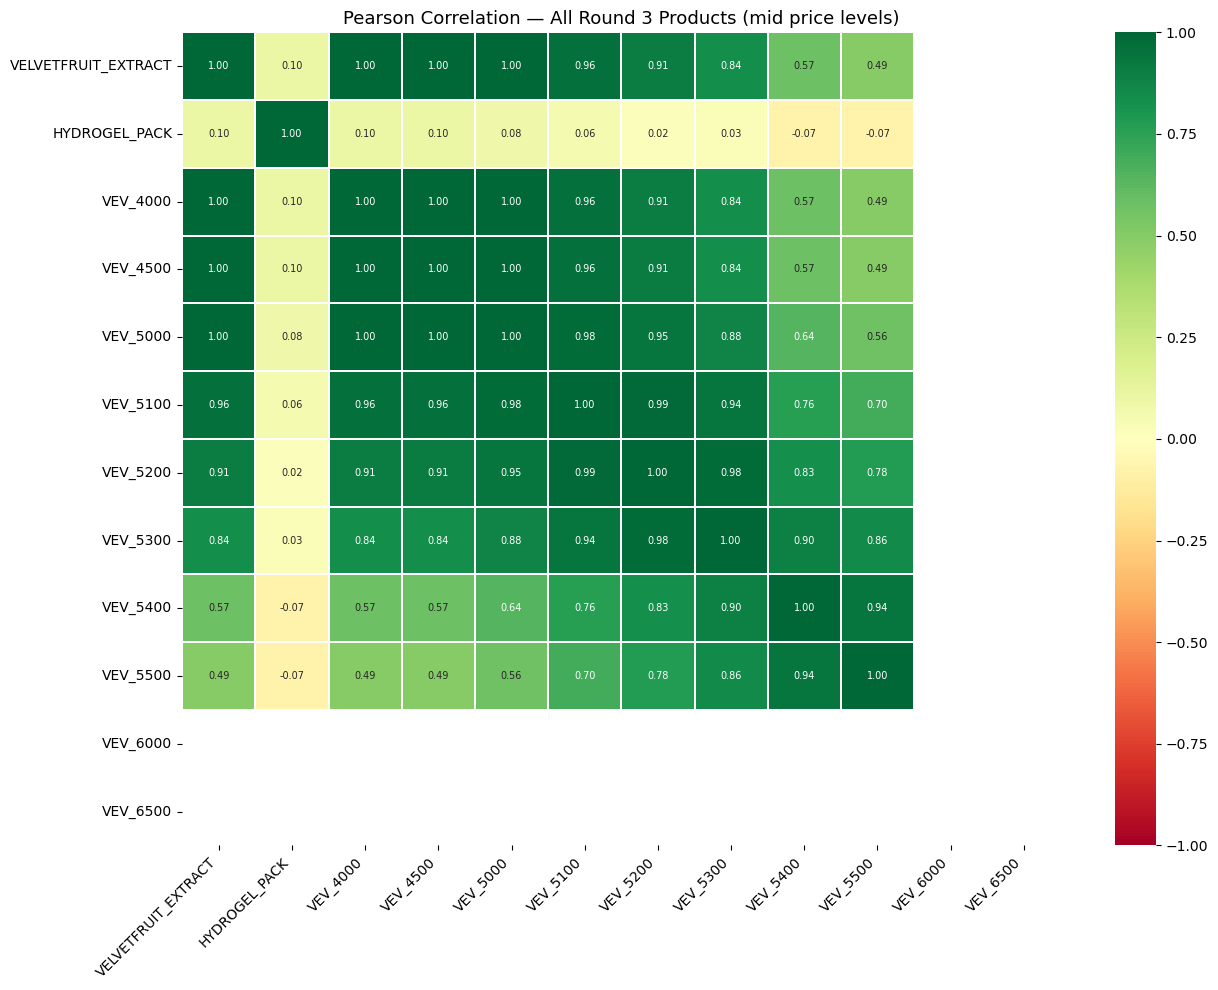

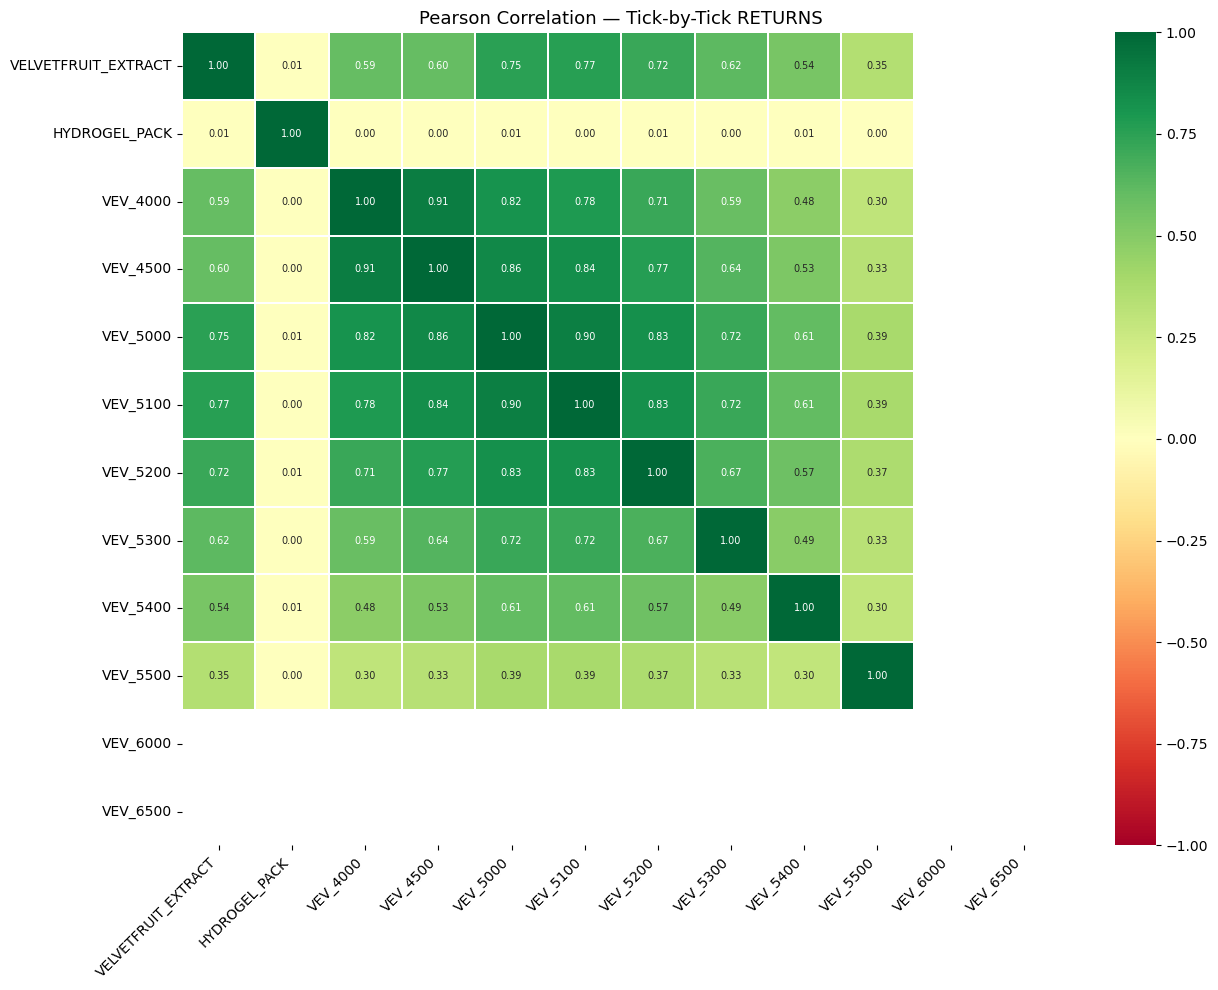

In [2]:
price_cols = [c for c in ALL_PRODUCTS if c in wide.columns]
corr = wide[price_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr, dtype=bool)
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, mask=mask,
            annot_kws={"size": 7}, linewidths=0.3)
ax.set_title("Pearson Correlation — All Round 3 Products (mid price levels)", fontsize=13)
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Returns correlation
ret_corr = wide[price_cols].diff().corr()
fig2, ax2 = plt.subplots(figsize=(13, 10))
sns.heatmap(ret_corr, ax=ax2, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, annot_kws={"size": 7}, linewidths=0.3)
ax2.set_title("Pearson Correlation — Tick-by-Tick RETURNS", fontsize=13)
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


## 2 — VELVETFRUIT_EXTRACT vs HYDROGEL_PACK

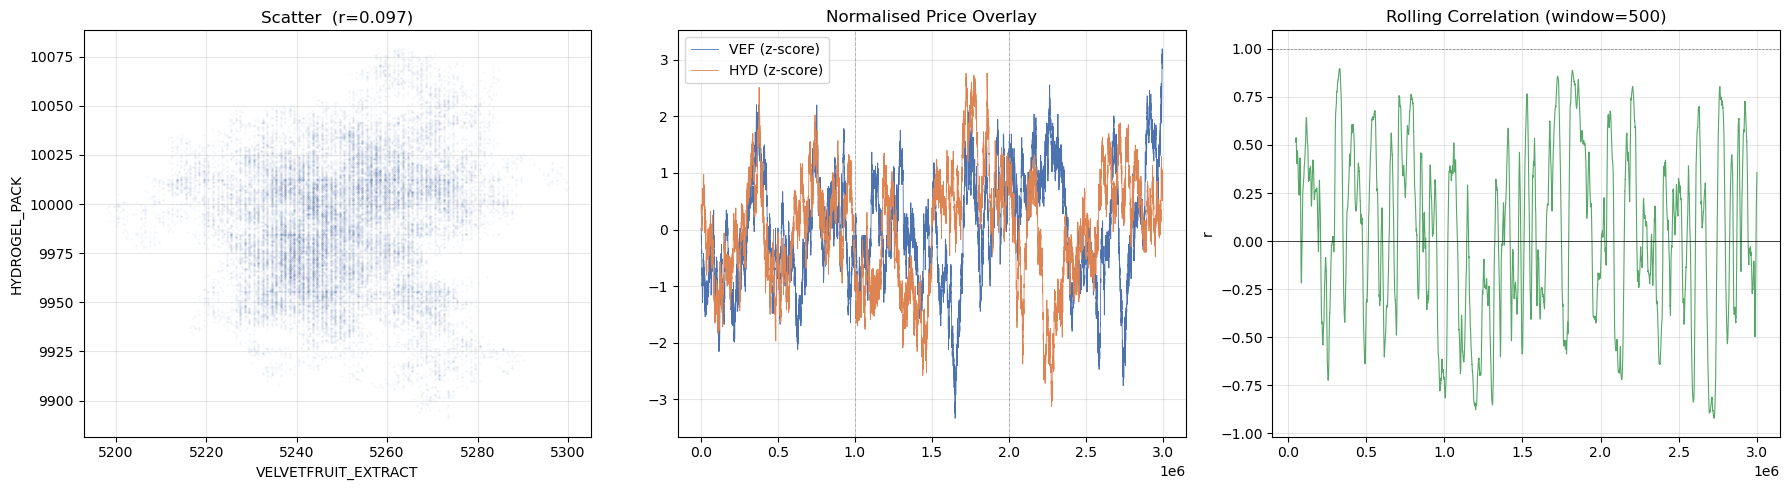

In [3]:
vef = wide["VELVETFRUIT_EXTRACT"].dropna()
hyd = wide["HYDROGEL_PACK"].dropna()
idx = vef.index.intersection(hyd.index)
vef_a, hyd_a = vef[idx], hyd[idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Scatter
axes[0].scatter(vef_a, hyd_a, alpha=0.03, s=1, color="#4C72B0")
axes[0].set_xlabel("VELVETFRUIT_EXTRACT"); axes[0].set_ylabel("HYDROGEL_PACK")
axes[0].set_title(f"Scatter  (r={vef_a.corr(hyd_a):.3f})"); axes[0].grid(True, alpha=0.3)

# Time-series overlay (normalised)
ts_x = wide.loc[idx, "global_ts"]
axes[1].plot(ts_x, (vef_a - vef_a.mean()) / vef_a.std(),
             color="#4C72B0", lw=0.6, label="VEF (z-score)")
axes[1].plot(ts_x, (hyd_a - hyd_a.mean()) / hyd_a.std(),
             color="#DD8452", lw=0.6, label="HYD (z-score)")
for i in range(1,3): axes[1].axvline(i*ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
axes[1].set_title("Normalised Price Overlay"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Rolling correlation
roll_corr = vef_a.rolling(500).corr(hyd_a)
axes[2].plot(ts_x, roll_corr, color="#55A868", lw=0.8)
axes[2].axhline(0, color="black", lw=0.5); axes[2].axhline(1, color="grey", ls="--", lw=0.5)
axes[2].set_title("Rolling Correlation (window=500)"); axes[2].set_ylabel("r")
axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3 — VELVETFRUIT_EXTRACT vs VEV Option Strikes

/Users/pieterrotteveel/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/pieterrotteveel/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


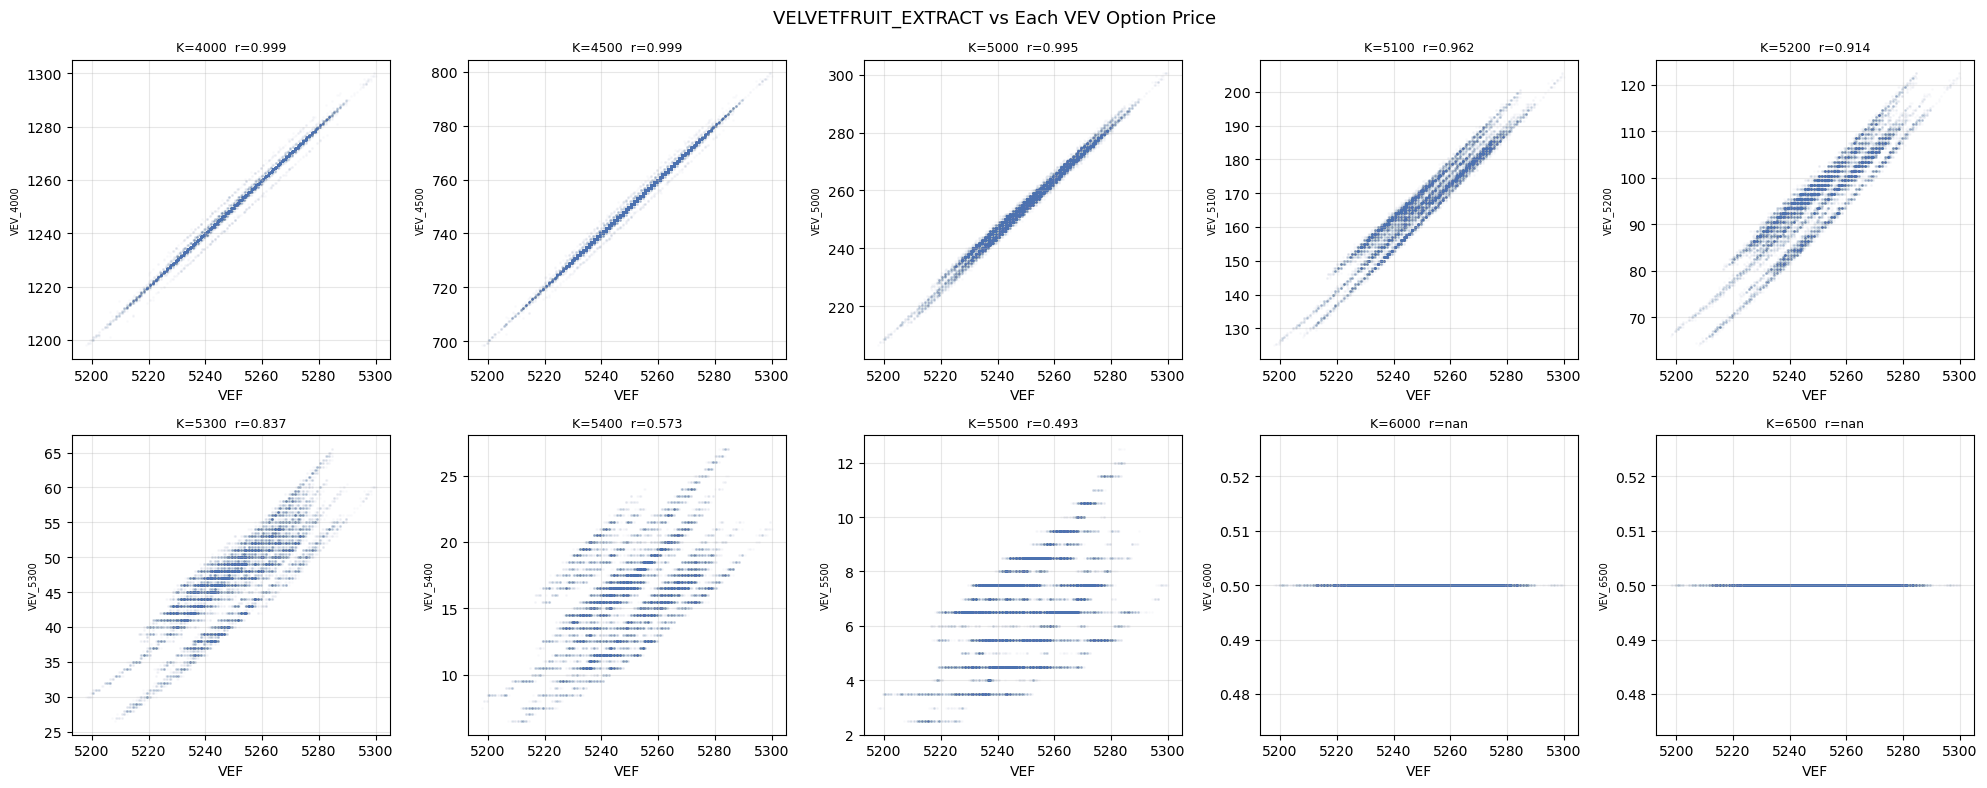

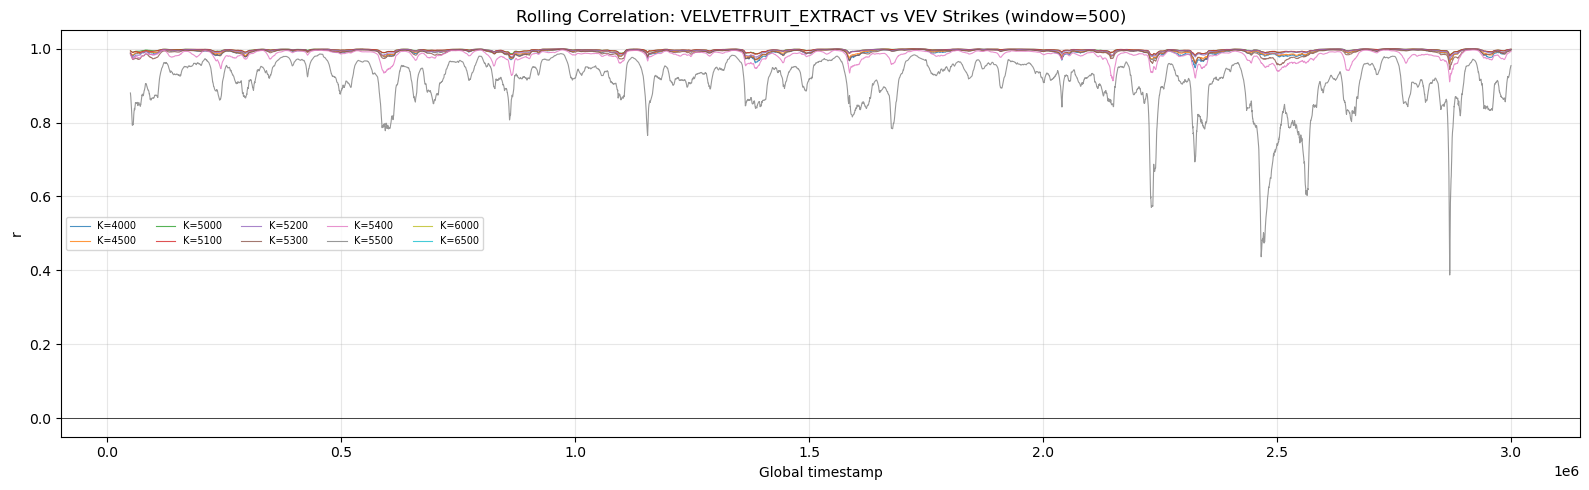

In [4]:
vef = wide["VELVETFRUIT_EXTRACT"]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, K in zip(axes.flatten(), STRIKES):
    col = f"VEV_{K}"
    if col not in wide.columns:
        continue
    vev = wide[col]
    idx = vef.dropna().index.intersection(vev.dropna().index)
    r   = vef[idx].corr(vev[idx])
    ax.scatter(vef[idx], vev[idx], alpha=0.02, s=1, color="#4C72B0")
    ax.set_title(f"K={K}  r={r:.3f}", fontsize=9)
    ax.set_xlabel("VEF"); ax.set_ylabel(f"VEV_{K}", fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle("VELVETFRUIT_EXTRACT vs Each VEV Option Price", fontsize=13)
plt.tight_layout(); plt.show()

# Rolling correlation per strike vs underlying
fig2, ax2 = plt.subplots(figsize=(16, 5))
colors_k = plt.cm.tab10(np.linspace(0, 1, len(STRIKES)))
for K, col in zip(STRIKES, colors_k):
    vcol = f"VEV_{K}"
    if vcol not in wide.columns: continue
    rc = wide["VELVETFRUIT_EXTRACT"].rolling(500).corr(wide[vcol])
    ax2.plot(wide["global_ts"], rc, lw=0.8, color=col, label=f"K={K}", alpha=0.8)
ax2.axhline(0, color="black", lw=0.5)
ax2.set_title("Rolling Correlation: VELVETFRUIT_EXTRACT vs VEV Strikes (window=500)")
ax2.set_xlabel("Global timestamp"); ax2.set_ylabel("r")
ax2.legend(fontsize=7, ncol=5); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4 — HYDROGEL_PACK vs VEV Options

      level_r  return_r
4000   0.0966    0.0017
4500   0.0968    0.0018
5000   0.0834    0.0056
5100   0.0619    0.0011
5200   0.0193    0.0071
5300   0.0302    0.0050
5400  -0.0749    0.0062
5500  -0.0716    0.0028
6000      NaN       NaN
6500      NaN       NaN


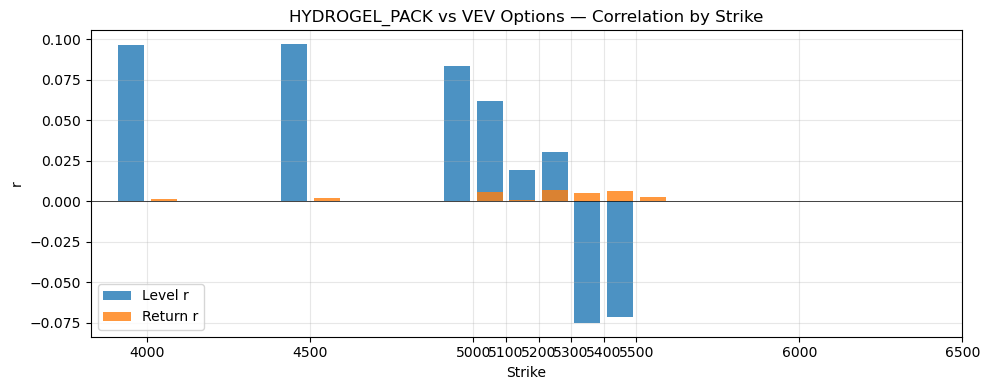

In [5]:
hyd = wide["HYDROGEL_PACK"]
corr_table = {}
for K in STRIKES:
    col = f"VEV_{K}"
    if col not in wide.columns: continue
    idx = hyd.dropna().index.intersection(wide[col].dropna().index)
    corr_table[K] = {"level_r": round(hyd[idx].corr(wide[col][idx]), 4),
                     "return_r": round(hyd[idx].diff().corr(wide[col][idx].diff()), 4)}
print(pd.DataFrame(corr_table).T.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ks = list(corr_table.keys())
ax.bar(np.array(ks)-50, [corr_table[k]["level_r"]  for k in ks], width=80, label="Level r",  alpha=0.8)
ax.bar(np.array(ks)+50, [corr_table[k]["return_r"] for k in ks], width=80, label="Return r", alpha=0.8)
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(ks); ax.set_xticklabels([str(k) for k in ks])
ax.set_title("HYDROGEL_PACK vs VEV Options — Correlation by Strike")
ax.set_xlabel("Strike"); ax.set_ylabel("r")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5 — Cointegration Analysis (Engle-Granger)

In [6]:
print("Running Engle-Granger cointegration tests…")
results = []
vef_s = wide["VELVETFRUIT_EXTRACT"].dropna()
hyd_s = wide["HYDROGEL_PACK"].dropna()

# VEF vs each VEV
for K in STRIKES:
    col = f"VEV_{K}"
    if col not in wide.columns: continue
    vev_s = wide[col].dropna()
    idx   = vef_s.index.intersection(vev_s.index)
    if len(idx) < 100: continue
    sc, pv, _ = coint(vef_s[idx], vev_s[idx])
    results.append({"Pair": f"VEF vs VEV_{K}", "Coint stat": round(sc,4),
                    "p-value": round(pv,4), "Cointegrated": pv < 0.05})

# VEF vs HYD
idx_vh = vef_s.index.intersection(hyd_s.index)
if len(idx_vh) > 100:
    sc, pv, _ = coint(vef_s[idx_vh], hyd_s[idx_vh])
    results.append({"Pair": "VEF vs HYD", "Coint stat": round(sc,4),
                    "p-value": round(pv,4), "Cointegrated": pv < 0.05})

print(pd.DataFrame(results).to_string(index=False))


Running Engle-Granger cointegration tests…
           Pair  Coint stat  p-value  Cointegrated
VEF vs VEV_4000    -76.8056   0.0000          True
VEF vs VEV_4500   -173.2903   0.0000          True
VEF vs VEV_5000     -2.1606   0.4448         False
VEF vs VEV_5100     -1.3245   0.8222         False
VEF vs VEV_5200     -1.2094   0.8554         False
VEF vs VEV_5300     -1.3222   0.8229         False
VEF vs VEV_5400     -2.9962   0.1111         False
VEF vs VEV_5500     -3.6101   0.0238          True
VEF vs VEV_6000     -4.8326   0.0003          True
VEF vs VEV_6500     -4.8326   0.0003          True
     VEF vs HYD     -4.8930   0.0003          True


## 6 — Spread Trading Signal (Time Value & Call Spread Residual)

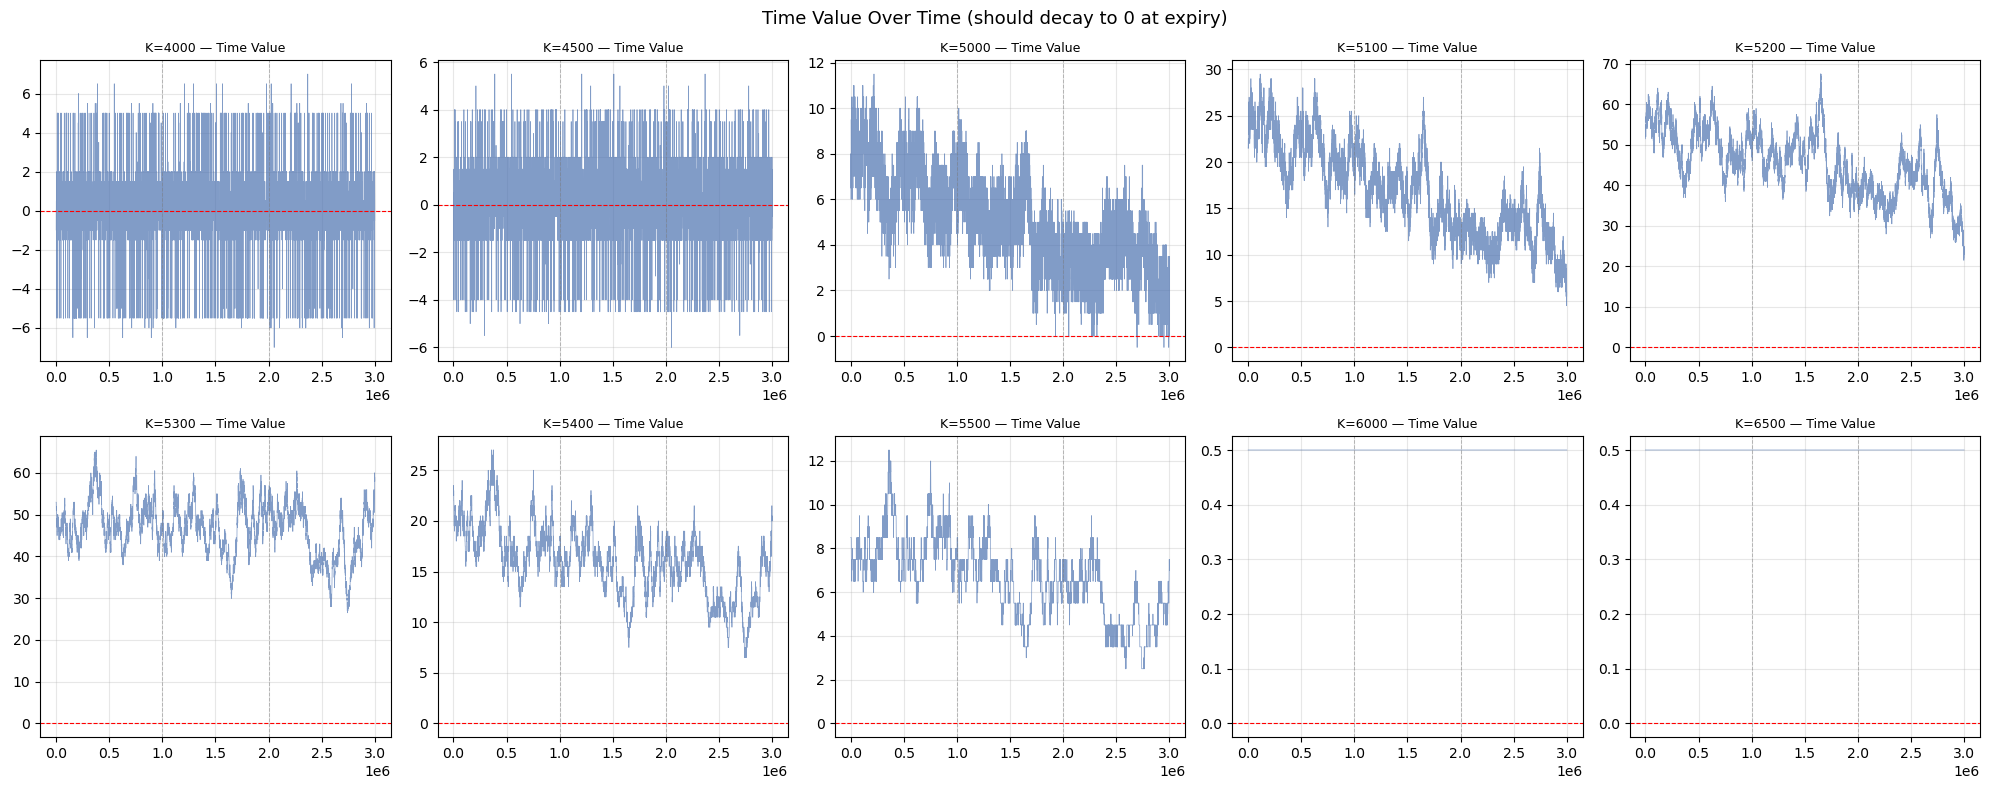

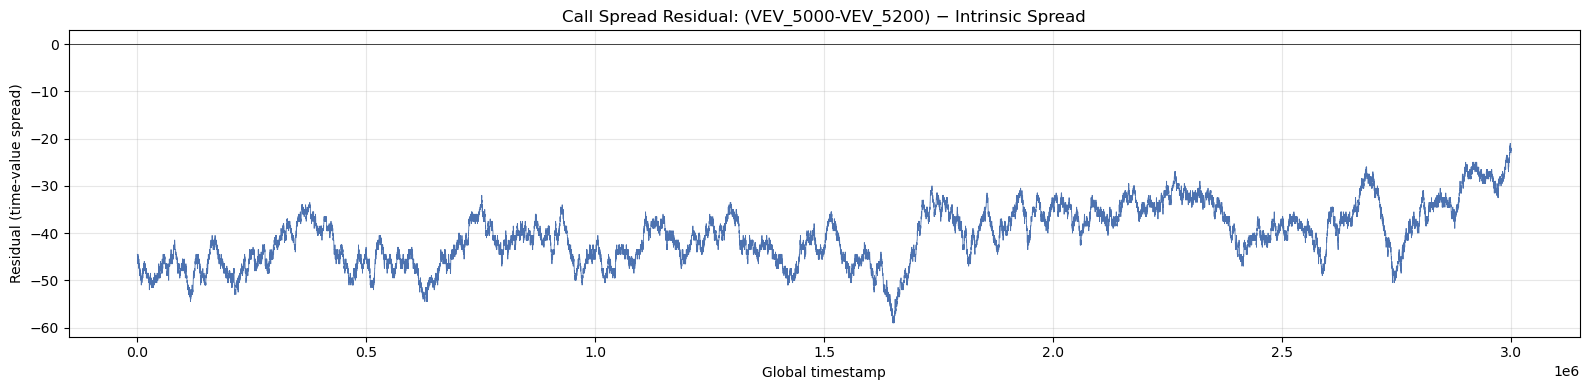

Residual stats: mean=-40.526  std=6.115


In [7]:
# Spread trading: C_theoretical - C_market residual
# For a call option: C_theo ≈ max(S-K, 0) (intrinsic lower bound)
# Richer signal: C_market - C_{nearby_strike} should move with delta * ΔS
vef = wide["VELVETFRUIT_EXTRACT"]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, K in zip(axes.flatten(), STRIKES):
    col = f"VEV_{K}"
    if col not in wide.columns: continue
    intrinsic = np.maximum(vef - K, 0)
    time_val  = wide[col] - intrinsic
    ax.plot(wide["global_ts"], time_val, lw=0.5, color="#4C72B0", alpha=0.7)
    ax.axhline(0, color="red", lw=0.8, ls="--")
    ax.set_title(f"K={K} — Time Value", fontsize=9); ax.grid(True, alpha=0.3)
    for i in range(1,3): ax.axvline(i*ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
fig.suptitle("Time Value Over Time (should decay to 0 at expiry)", fontsize=13)
plt.tight_layout(); plt.show()

# Call spread residual: VEV_K1 - VEV_K2 vs theoretical spread (delta * (K2-K1))
K1, K2 = 5000, 5200
if f"VEV_{K1}" in wide.columns and f"VEV_{K2}" in wide.columns:
    spread_mkt  = wide[f"VEV_{K1}"] - wide[f"VEV_{K2}"]
    spread_theo = np.maximum(vef - K1, 0) - np.maximum(vef - K2, 0)
    residual    = spread_mkt - spread_theo

    fig2, ax2 = plt.subplots(figsize=(16, 4))
    ax2.plot(wide["global_ts"], residual, lw=0.6, color="#4C72B0")
    ax2.axhline(0, color="black", lw=0.5)
    ax2.set_title(f"Call Spread Residual: (VEV_{K1}-VEV_{K2}) − Intrinsic Spread")
    ax2.set_xlabel("Global timestamp"); ax2.set_ylabel("Residual (time-value spread)")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"Residual stats: mean={residual.mean():.3f}  std={residual.std():.3f}")


## 7 — Cross-Product Returns Correlation & Lead-Lag

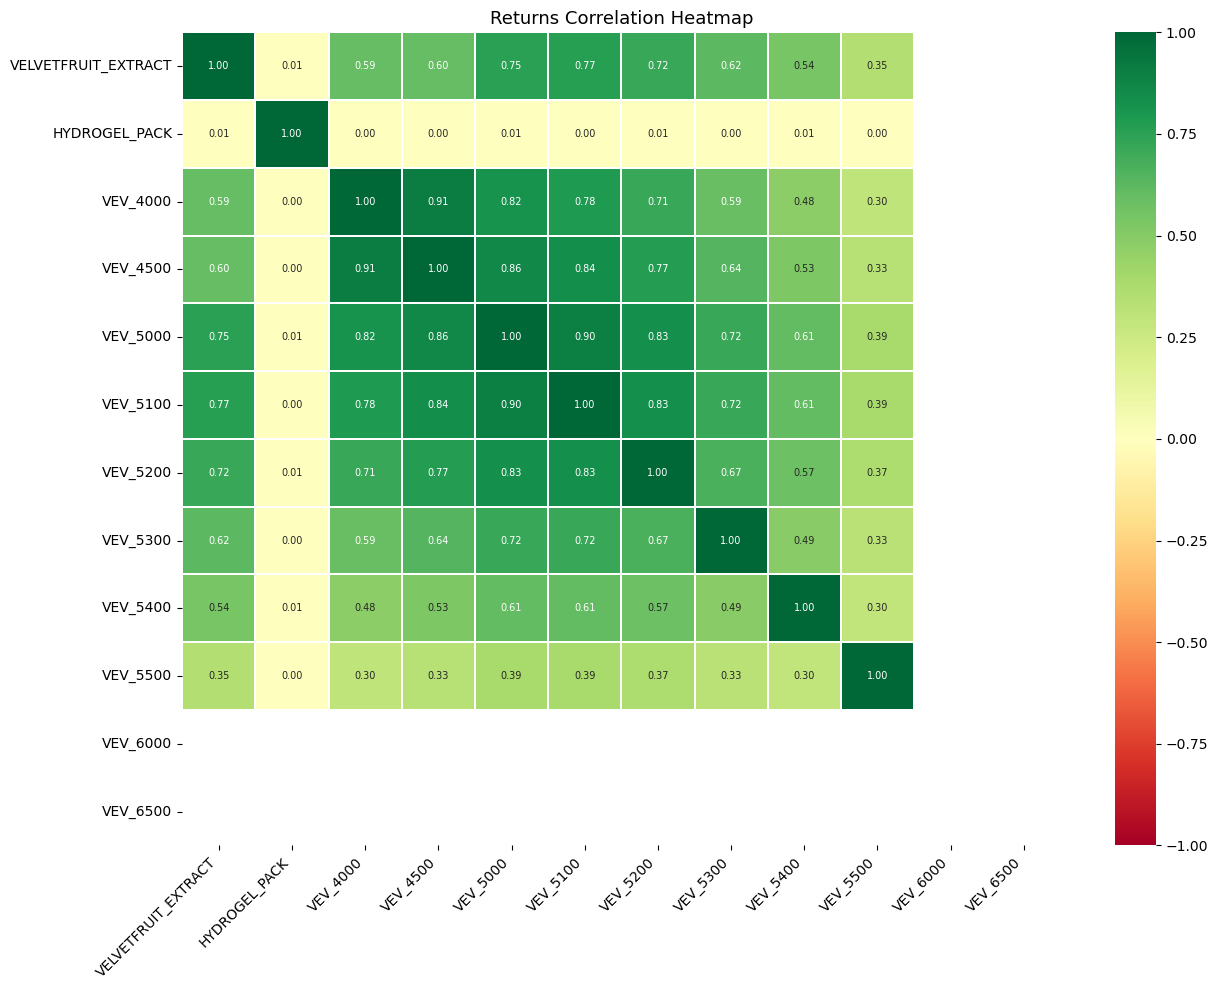

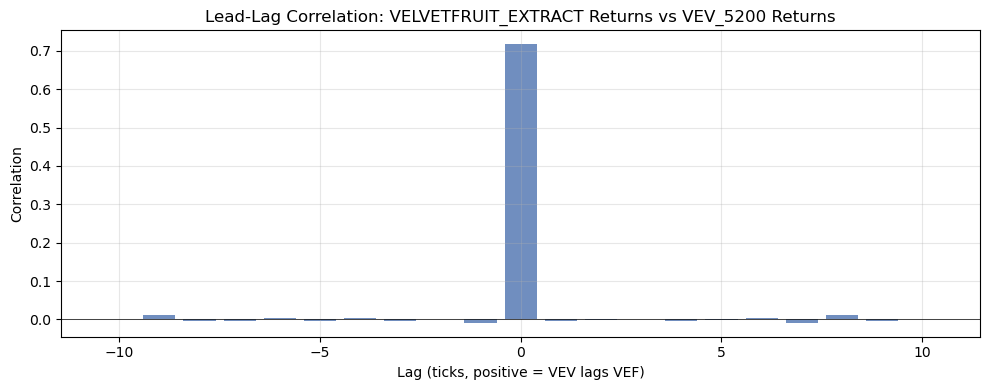

In [8]:
ret_cols = [c for c in ALL_PRODUCTS if c in wide.columns]
rets = wide[ret_cols].diff()

# Heatmap
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(rets.corr(), ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, annot_kws={"size":7}, linewidths=0.3)
ax.set_title("Returns Correlation Heatmap", fontsize=13)
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Lead-lag between VEF and VEV_5200 (ATM option)
if "VEV_5200" in wide.columns:
    vef_r = wide["VELVETFRUIT_EXTRACT"].diff().dropna()
    vev_r = wide["VEV_5200"].diff().dropna()
    lags  = range(-10, 11)
    idx   = vef_r.index.intersection(vev_r.index)
    ll    = [vef_r[idx].corr(vev_r[idx].shift(l)) for l in lags]
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.bar(list(lags), ll, color="#4C72B0", alpha=0.8)
    ax2.axhline(0, color="black", lw=0.5)
    ax2.set_title("Lead-Lag Correlation: VELVETFRUIT_EXTRACT Returns vs VEV_5200 Returns")
    ax2.set_xlabel("Lag (ticks, positive = VEV lags VEF)")
    ax2.set_ylabel("Correlation"); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
